# 6CS012 Final Portfolio Project 2026
# Image Classification with Convolutional Neural Networks
**Dataset:** Waste Classification

**Student:** Kunsang Lhamu Tamang

**Date:**  May 10

**Module:** 6CS012 — Artificial Intelligence

# 0. Install & Import All Required Libraries

In [1]:
# ── Environment setup ──
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# ── Core scientific libraries ──
import numpy as np
import matplotlib.pyplot as plt
import time
import os, sys

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam, SGD

# ── Scikit-learn ──
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from PIL import Image

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpus[0].name if gpus else "None — use Runtime > Change runtime type > T4"}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : /physical_device:GPU:0


#  Part A — Section 1: Data Understanding, Analysis & Visualisation

In [3]:
# ── Mount Google Drive ──
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_DIR = '/content/drive/MyDrive/Waste Classification'
else:
    DATASET_DIR = r'C:\Users\PAVILION PLUS\OneDrive\Desktop\Waste Classification'

print('Dataset path:', DATASET_DIR)

# ── Load images from disk ──
IMG_SIZE_LOAD = 128
CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
print('Classes:', CLASS_NAMES)
print(f'Total classes found: {len(CLASS_NAMES)}')

images, labels = [], []
for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_DIR, class_name)
    for sub in ['default', 'real_world']:
        sub_dir = os.path.join(class_dir, sub)
        if not os.path.isdir(sub_dir):
            continue
        for fname in os.listdir(sub_dir):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img = Image.open(os.path.join(sub_dir, fname)).convert('RGB')
            img = img.resize((IMG_SIZE_LOAD, IMG_SIZE_LOAD))
            images.append(np.array(img))
            labels.append(label_idx)

X_all = np.array(images, dtype='uint8')
y_all = np.array(labels)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f'Total images          : {len(X_all)}')
print(f'Training images shape : {X_train_raw.shape}')
print(f'Test images shape     : {X_test_raw.shape}')
print(f'Number of classes     : {len(CLASS_NAMES)}')
print(f'Pixel value range     : {X_train_raw.min()} – {X_train_raw.max()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/Waste Classification
Classes: ['aluminum_food_cans', 'cardboard_boxes', 'food_waste', 'glass_beverage_bottles', 'newspaper', 'paper_cups', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'styrofoam_food_containers']
Total classes found: 10
Total images          : 3000
Training images shape : (2400, 128, 128, 3)
Test images shape     : (600, 128, 128, 3)
Number of classes     : 10
Pixel value range     : 0 – 255


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


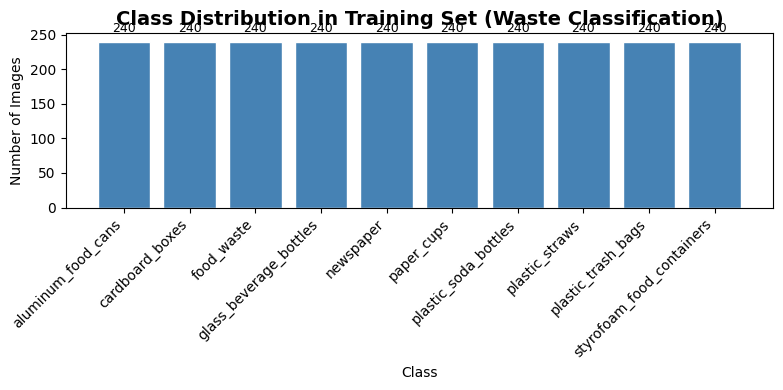

Observation: Found 10 classes. Unique label indices: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# ── Class distribution plot ──
unique, counts = np.unique(y_train_raw, return_counts=True)

# Map unique label indices → class names (handles missing classes gracefully)
class_labels = [CLASS_NAMES[i] for i in unique]

plt.figure(figsize=(8, 4))
bars = plt.bar(class_labels, counts, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Training Set (Waste Classification)', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(f'Observation: Found {len(unique)} classes. Unique label indices: {unique}')


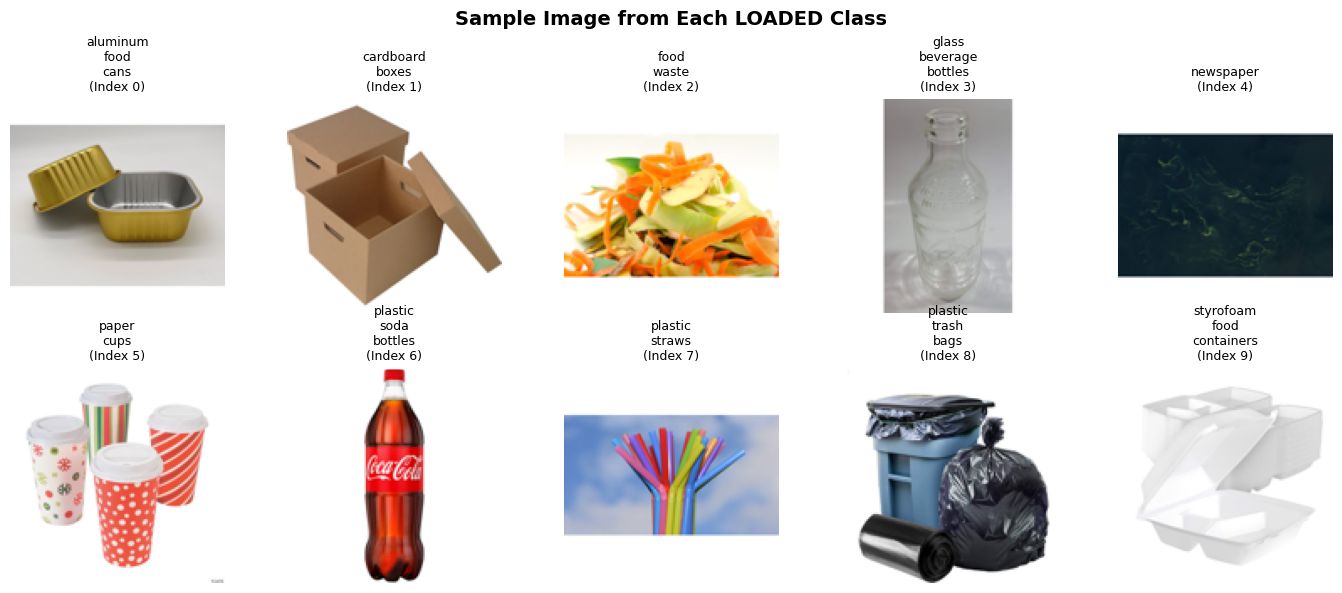

In [ ]:
# ── Visualise sample images (Robust Version) ──
unique_classes = np.unique(y_train_raw)
num_to_show = len(unique_classes)

# Create a dynamic grid based on how many classes were actually loaded
cols = 5
rows = (num_to_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
fig.suptitle('Sample Image from Each LOADED Class', fontsize=14, fontweight='bold')

for i, idx in enumerate(unique_classes):
    ax = axes.flat[i] if num_to_show > 1 else axes

    # Get the first image belonging to this class
    sample_indices = np.where(y_train_raw == idx)[0]
    if len(sample_indices) > 0:
        sample_idx = sample_indices[0]
        ax.imshow(X_train_raw[sample_idx])
        ax.set_title(f"{CLASS_NAMES[idx].replace('_', '\n')}\n(Index {idx})", fontsize=9)

    ax.axis('off')

# Hide any empty subplots
for j in range(i + 1, rows * cols):
    axes.flat[j].axis('off')

plt.tight_layout()
plt.show()

if len(unique_classes) < 10:
    print(f" Warning: Only {len(unique_classes)}/10 classes loaded. Check Google Drive sync!")


In [ ]:
# ── Pre-processing: Normalisation ──
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

NUM_CLASSES = len(CLASS_NAMES)   # e.g. 10
BATCH_SIZE  = 64

y_train = keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = keras.utils.to_categorical(y_test_raw,  NUM_CLASSES)

print('After normalisation:')
print(f'  X_train pixel range : {X_train.min():.2f} – {X_train.max():.2f}')
print(f'  y_train shape       : {y_train.shape}   (one-hot)')
print(f'  NUM_CLASSES         : {NUM_CLASSES}')

After normalisation:
  X_train pixel range : 0.00 – 1.00
  y_train shape       : (2400, 10)   (one-hot)
  NUM_CLASSES         : 10


In [ ]:
# ── Data Augmentation ──
train_datagen = ImageDataGenerator(
    horizontal_flip    = True,
    rotation_range     = 15,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.1,
    validation_split   = 0.1
)

val_datagen = ImageDataGenerator(validation_split=0.1)

train_generator = train_datagen.flow(
    X_train, y_train, batch_size=BATCH_SIZE, subset='training', seed=42)
val_generator = val_datagen.flow(
    X_train, y_train, batch_size=BATCH_SIZE, subset='validation', seed=42)

print(f'Training batches   : {len(train_generator)}')
print(f'Validation batches : {len(val_generator)}')

Training batches   : 34
Validation batches : 4


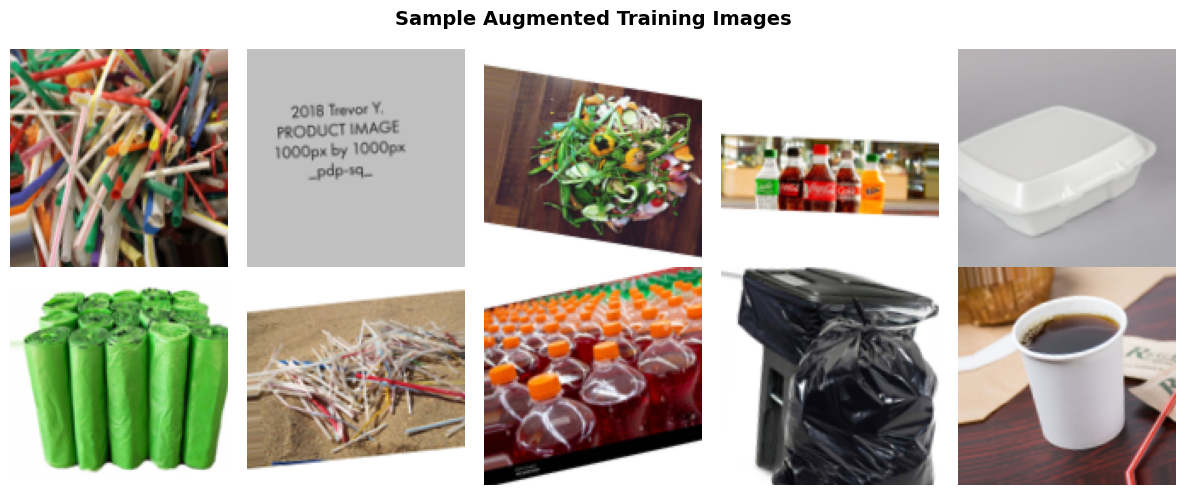

Note: Each image has been slightly rotated, flipped, or shifted. This helps the model generalise to unseen images.


In [ ]:
# ── Visualise augmented images ──
sample_images, _ = next(train_generator)   # grab one batch

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')
for ax, img in zip(axes.flat, sample_images[:10]):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150)
plt.show()
print('Note: Each image has been slightly rotated, flipped, or shifted. '
      'This helps the model generalise to unseen images.')

#  Part A — Section 2: Baseline CNN Model

In [ ]:
# ── Build Baseline CNN ──
# Input: 128×128 colour images (3 channels)
# Architecture:
#   Block 1: Conv(32 filters, 3×3) → ReLU → MaxPool(2×2)
#   Block 2: Conv(64 filters, 3×3) → ReLU → MaxPool(2×2)
#   Block 3: Conv(64 filters, 3×3) → ReLU → MaxPool(2×2)
#   Flatten → Dense(256) → Dense(128) → Dense(64) → Dense(10, softmax)

def build_baseline_model():
    model = models.Sequential(name='Baseline_CNN')
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=(128,128,3), name='conv1'))
    model.add(layers.MaxPooling2D((2,2), name='pool1'))   # 64x64
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))   # 32x32
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv3'))
    model.add(layers.MaxPooling2D((2,2), name='pool3'))   # 16x16
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='fc1'))
    model.add(layers.Dense(128, activation='relu', name='fc2'))
    model.add(layers.Dense(64,  activation='relu', name='fc3'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,292,682 (16.38 MB)

 Trainable params: 4,292,682 (16.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Baseline Model ──
EPOCHS = 30

early_stop_baseline = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    callbacks       = [early_stop_baseline],
    verbose         = 1
)

baseline_training_time = time.time() - start_time
print(f'\nBaseline model training time: {baseline_training_time:.1f}s  '
      f'({baseline_training_time/60:.1f} min)')

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 497ms/step - accuracy: 0.1352 - loss: 2.3047 - val_accuracy: 0.1792 - val_loss: 2.1639
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.3394 - loss: 1.8841 - val_accuracy: 0.3375 - val_loss: 1.8656
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 342ms/step - accuracy: 0.4403 - loss: 1.6475 - val_accuracy: 0.4125 - val_loss: 1.6968
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.4912 - loss: 1.5183 - val_accuracy: 0.4250 - val_loss: 1.7019
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.5333 - loss: 1.4077 - val_accuracy: 0.4500 - val_loss: 1.6432
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.5500 - loss: 1.3342 - val_accuracy: 0.5250 - val_loss: 1.5165
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 379ms/step - accuracy: 0.5588 - loss: 1.2969 - val_accuracy: 0.5125 - val_loss: 1.4870
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step - accuracy: 0.5847 - loss: 1.2381 - val_accura

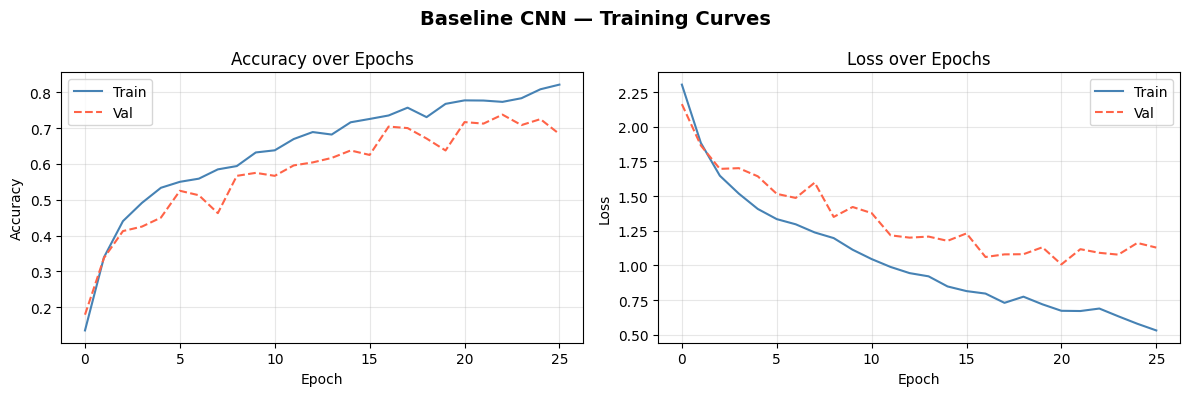

Figure saved: baseline_curves.png


In [ ]:
# ── Helper: Plot Training Curves ──
def plot_training_curves(history, title='Training Curves', save_name='curves.png'):
    """Plots accuracy and loss curves for training vs validation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train',  color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val',    color='tomato', linestyle='--')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val',   color='tomato', linestyle='--')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {save_name}')

# Plot baseline curves immediately after training
plot_training_curves(baseline_history, 'Baseline CNN — Training Curves', 'baseline_curves.png')

In [ ]:
# ── Evaluate Baseline Model (Sync-Aware) ──
y_pred_probs_base = baseline_model.predict(X_test, verbose=0)
y_pred_base       = np.argmax(y_pred_probs_base, axis=1)

# Detect which classes actually exist in the test set to avoid crashes
present_indices = np.unique(np.concatenate([y_test_raw, y_pred_base]))
present_names   = [CLASS_NAMES[i] for i in present_indices]

print('=== Baseline Model — Classification Report ===')
# Pass the 'labels' parameter to tell sklearn exactly which indices to look for
print(classification_report(y_test_raw, y_pred_base,
                            labels=present_indices,
                            target_names=present_names))

# Overall test accuracy
test_loss_base, test_acc_base = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc_base*100:.2f}%')
print(f'Test Loss     : {test_loss_base:.4f}')

# Diagnostic: Identify the missing class
if len(present_indices) < 10:
    all_indices = set(range(10))
    missing = all_indices - set(present_indices)
    print(f"\nWARNING: Your Drive is still syncing. Missing classes: {[CLASS_NAMES[i] for i in missing]}")


=== Baseline Model — Classification Report ===
                           precision    recall  f1-score   support

       aluminum_food_cans       0.71      0.60      0.65        60
          cardboard_boxes       0.83      0.73      0.78        60
               food_waste       0.69      0.92      0.79        60
   glass_beverage_bottles       0.80      0.75      0.78        60
                newspaper       0.54      0.72      0.62        60
               paper_cups       0.59      0.55      0.57        60
     plastic_soda_bottles       0.63      0.75      0.69        60
           plastic_straws       0.92      0.58      0.71        60
       plastic_trash_bags       0.87      0.75      0.80        60
styrofoam_food_containers       0.80      0.85      0.82        60

                 accuracy                           0.72       600
                macro avg       0.74      0.72      0.72       600
             weighted avg       0.74      0.72      0.72       600

Test Accurac

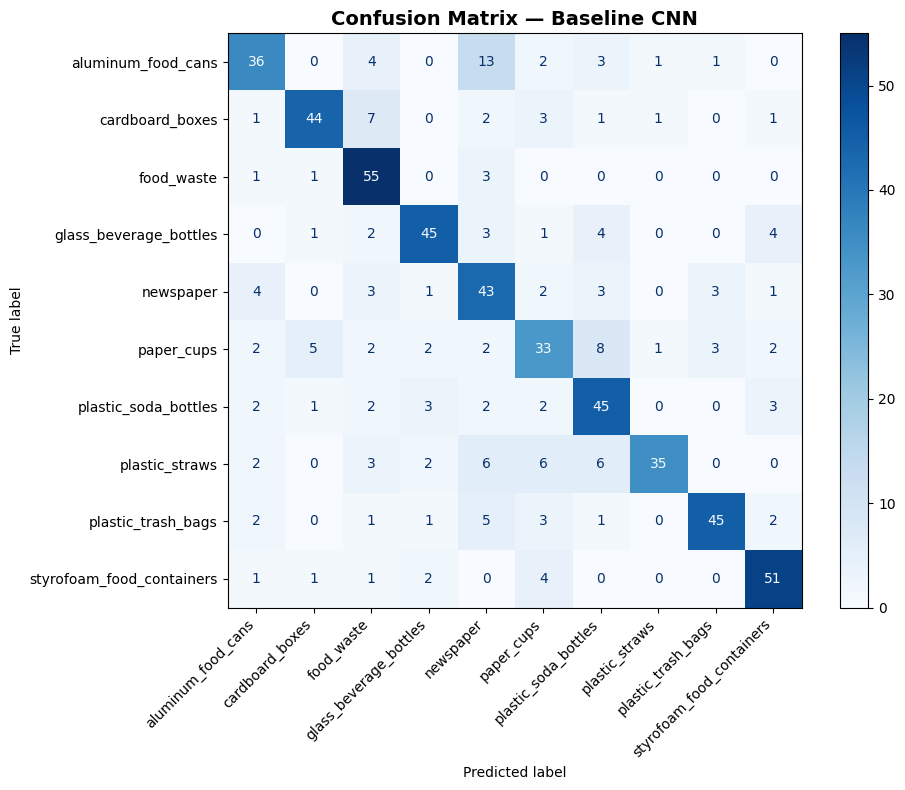

In [ ]:
# ── Confusion Matrix (Sync-Aware) ──
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate CM for classes that are actually present
cm_base = confusion_matrix(y_test_raw, y_pred_base)

# Dynamically get the names for the 9 classes that exist
present_indices = np.unique(np.concatenate([y_test_raw, y_pred_base]))
present_names   = [CLASS_NAMES[i] for i in present_indices]

# Use the dynamic names for display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=present_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title('Confusion Matrix — Baseline CNN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('baseline_cm.png', dpi=150)
plt.show()


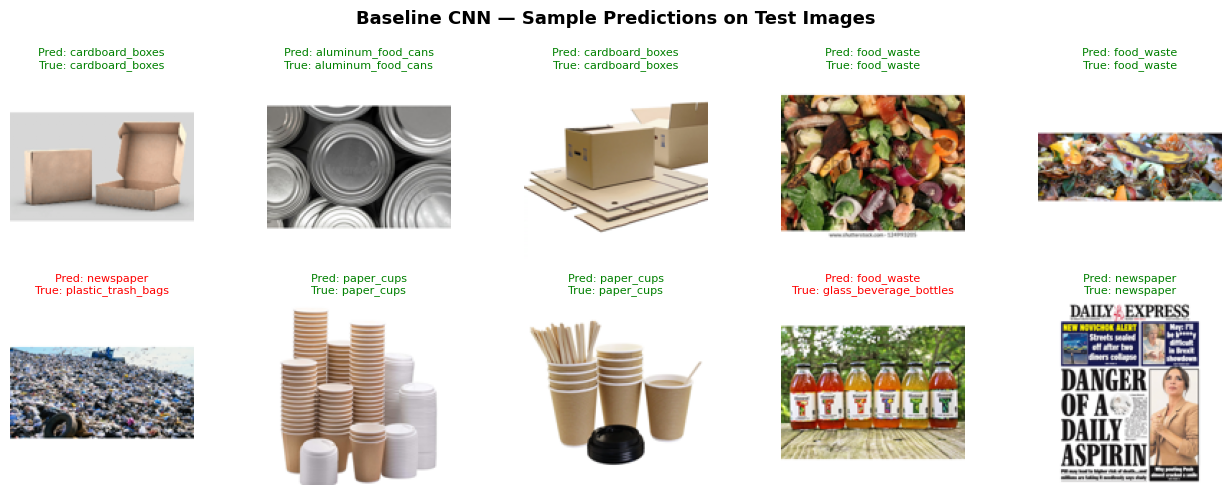

Green title = correct prediction | Red title = incorrect prediction


In [ ]:
# ── Sample Inference: show 10 predictions visually ──
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
fig.suptitle('Baseline CNN — Sample Predictions on Test Images', fontsize=13, fontweight='bold')

indices = np.random.choice(len(X_test), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx])
    pred  = CLASS_NAMES[y_pred_base[idx]]
    truth = CLASS_NAMES[y_test_raw[idx]]
    color = 'green' if pred == truth else 'red'
    ax.set_title(f'Pred: {pred}\nTrue: {truth}', color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()
print('Green title = correct prediction | Red title = incorrect prediction')

# Part A — Section 3: Deeper CNN with Regularisation

In [ ]:
# ── Build Deeper CNN (Improved Architecture) ──
# 5 Convolutional blocks with BatchNorm + Dropout
# Uses GlobalAveragePooling instead of Flatten (fewer params, less overfitting)
# Input: 128×128×3

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD

def build_deeper_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    """
    Improved deeper CNN:
    - 5 conv blocks (32→64→128→256→512 filters)
    - BatchNormalization after every conv layer
    - Dropout after every pooling / before dense layers
    - GlobalAveragePooling2D instead of Flatten (reduces overfitting)
    """
    model = models.Sequential(name='Deeper_CNN')

    # === Block 1: 32 filters ===
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu',
                            input_shape=input_shape, name='conv1a'))
    model.add(layers.BatchNormalization(name='bn1a'))
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1b'))
    model.add(layers.BatchNormalization(name='bn1b'))
    model.add(layers.MaxPooling2D((2,2), name='pool1'))
    model.add(layers.Dropout(0.25, name='drop1'))

    # === Block 2: 64 filters ===
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2a'))
    model.add(layers.BatchNormalization(name='bn2a'))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2b'))
    model.add(layers.BatchNormalization(name='bn2b'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))
    model.add(layers.Dropout(0.25, name='drop2'))

    # === Block 3: 128 filters ===
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3a'))
    model.add(layers.BatchNormalization(name='bn3a'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3b'))
    model.add(layers.BatchNormalization(name='bn3b'))
    model.add(layers.MaxPooling2D((2,2), name='pool3'))
    model.add(layers.Dropout(0.25, name='drop3'))

    # === Block 4: 256 filters ===
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu', name='conv4a'))
    model.add(layers.BatchNormalization(name='bn4a'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu', name='conv4b'))
    model.add(layers.BatchNormalization(name='bn4b'))
    model.add(layers.MaxPooling2D((2,2), name='pool4'))
    model.add(layers.Dropout(0.3, name='drop4'))

    # === Block 5: 512 filters ===
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu', name='conv5a'))
    model.add(layers.BatchNormalization(name='bn5a'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu', name='conv5b'))
    model.add(layers.BatchNormalization(name='bn5b'))
    # GlobalAveragePooling2D: replaces Flatten, drastically reduces params
    model.add(layers.GlobalAveragePooling2D(name='gap'))
    model.add(layers.Dropout(0.4, name='drop5'))

    # === Fully Connected Head ===
    model.add(layers.Dense(512, activation='relu', name='fc1'))
    model.add(layers.BatchNormalization(name='bn_fc1'))
    model.add(layers.Dropout(0.5, name='drop_fc1'))

    model.add(layers.Dense(256, activation='relu', name='fc2'))
    model.add(layers.BatchNormalization(name='bn_fc2'))
    model.add(layers.Dropout(0.5, name='drop_fc2'))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer = Adam(learning_rate=0.003),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()

total_params = deeper_model.count_params()
print(f'\nTotal parameters: {total_params:,}')


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)       │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3b (BatchNormalization)       │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4a (Conv2D)                 │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4a (BatchNormalization)       │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4b (Conv2D)                 │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4b (BatchNormalization)       │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5a (Conv2D)                 │ (None, 8, 8, 256)      │       590,08

 Total params: 2,626,858 (10.02 MB)

 Trainable params: 2,622,378 (10.00 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total parameters: 2,626,858


In [ ]:
# ── Train Deeper CNN (direct array, not generator) ──

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

early_stop_deep = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint(
    'best_deeper_model.keras', monitor='val_accuracy',
    save_best_only=True, verbose=1)

start_time = time.time()

deeper_history = deeper_model.fit(      # FIX: was 'history'
    X_train,
    y_train,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [reduce_lr, early_stop_deep, checkpoint],
    shuffle         = True,
    verbose         = 1
)

deeper_training_time = time.time() - start_time    # FIX: was never assigned
print(f'\nDeeper CNN training time: {deeper_training_time:.1f}s  '
      f'({deeper_training_time/60:.1f} min)')

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.1942 - loss: 3.0483
Epoch 1: val_accuracy improved from None to 0.10833, saving model to best_deeper_model.keras

Epoch 1: finished saving model to best_deeper_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 53s 392ms/step - accuracy: 0.2282 - loss: 2.8002 - val_accuracy: 0.1083 - val_loss: 16.0254 - learning_rate: 0.0030
Epoch 2/50
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3015 - loss: 2.2436
Epoch 2: val_accuracy improved from 0.10833 to 0.17500, saving model to best_deeper_model.keras

Epoch 2: finished saving model to best_deeper_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.3106 - loss: 2.2180 - val_accuracy: 0.1750 - val_loss: 4.2113 - learning_rate: 0.0030
Epoch 3/50
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3468 - loss: 2.0118
Epoch 3: val_accuracy improved from 0.17500 to 0.18750, saving model to best_deeper_model.keras

Epoch 3: finished saving model to best_deeper_model.keras

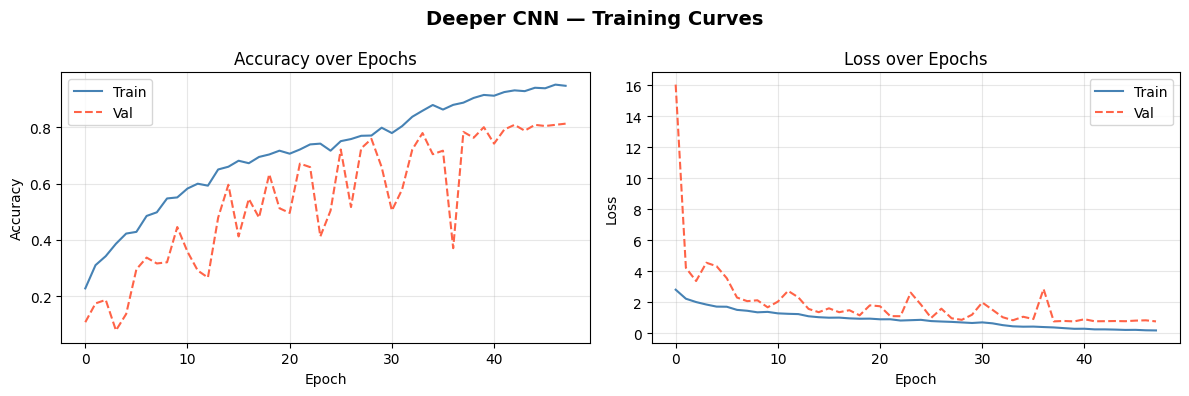

Figure saved: deeper_curves.png
=== Deeper Model — Classification Report ===
                           precision    recall  f1-score   support

       aluminum_food_cans       0.66      0.80      0.72        60
          cardboard_boxes       0.73      0.82      0.77        60
               food_waste       0.86      0.95      0.90        60
   glass_beverage_bottles       0.80      0.92      0.85        60
                newspaper       0.73      0.75      0.74        60
               paper_cups       0.74      0.57      0.64        60
     plastic_soda_bottles       0.73      0.80      0.76        60
           plastic_straws       0.88      0.72      0.79        60
       plastic_trash_bags       0.92      0.77      0.84        60
styrofoam_food_containers       0.90      0.78      0.84        60

                 accuracy                           0.79       600
                macro avg       0.79      0.79      0.79       600
             weighted avg       0.79      0.79    

In [ ]:
# ── Plot Deeper CNN Training Curves ──
plot_training_curves(deeper_history, 'Deeper CNN — Training Curves', 'deeper_curves.png')

# ── Evaluate on test set ──
y_pred_probs_deep = deeper_model.predict(X_test, verbose=0)
y_pred_deep       = np.argmax(y_pred_probs_deep, axis=1)

print('=== Deeper Model — Classification Report ===')
print(classification_report(y_test_raw, y_pred_deep, target_names=CLASS_NAMES))

test_loss_deep, test_acc_deep = deeper_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc_deep*100:.2f}%')
print(f'Test Loss     : {test_loss_deep:.4f}')

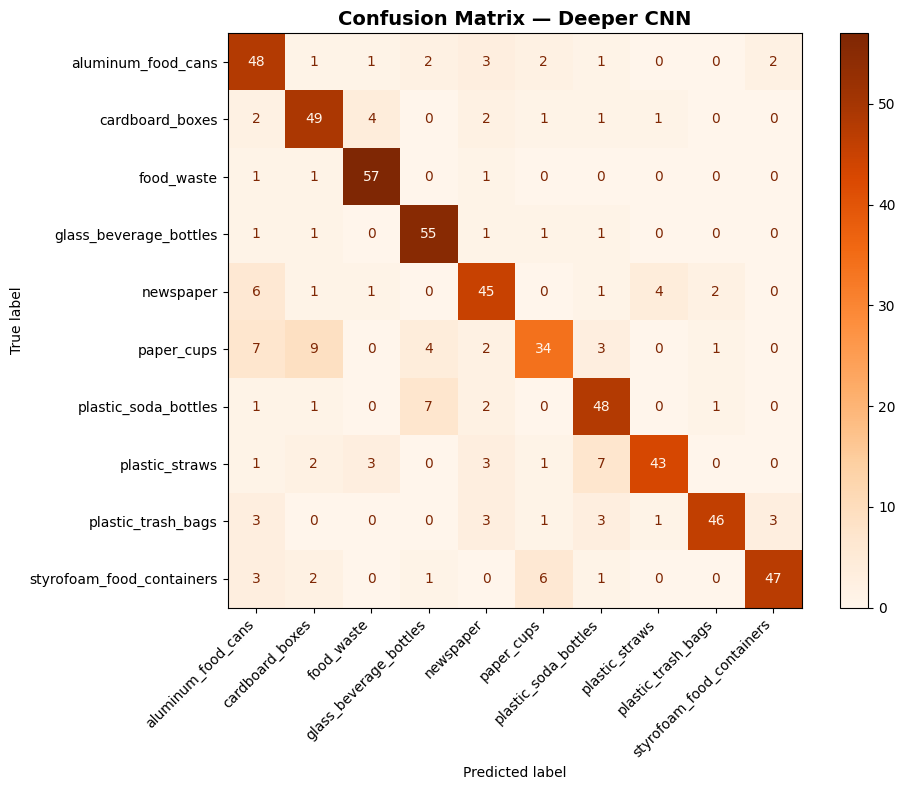

Figure saved: deeper_cm.png


In [ ]:
# ── Confusion Matrix — Deeper CNN ──
cm_deep = confusion_matrix(y_test_raw, y_pred_deep)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Oranges', colorbar=True)
ax.set_title('Confusion Matrix — Deeper CNN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('deeper_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: deeper_cm.png')

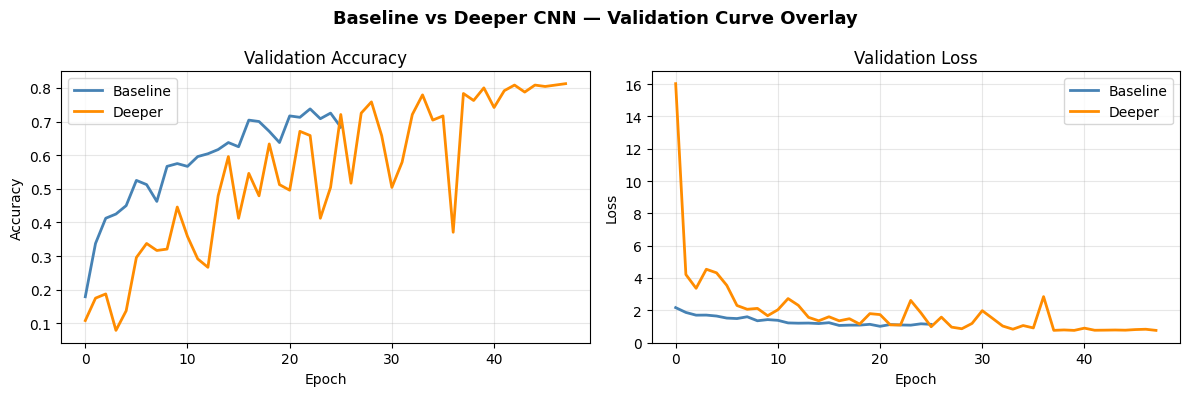

Baseline stopped at epoch: 26
Deeper   stopped at epoch: 48
Observation: The Deeper CNN shows improved accuracy and a tighter train-val gap.


In [ ]:
# ── Overlay: Baseline vs Deeper Validation Curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Baseline vs Deeper CNN — Validation Curve Overlay',
             fontsize=13, fontweight='bold')

ax1.plot(baseline_history.history['val_accuracy'],
         label='Baseline', color='steelblue', linewidth=2)
ax1.plot(deeper_history.history['val_accuracy'],
         label='Deeper',   color='darkorange', linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(baseline_history.history['val_loss'],
         label='Baseline', color='steelblue', linewidth=2)
ax2.plot(deeper_history.history['val_loss'],
         label='Deeper',   color='darkorange', linewidth=2)
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overlay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline stopped at epoch: {len(baseline_history.history["val_loss"])}')
print(f'Deeper   stopped at epoch: {len(deeper_history.history["val_loss"])}')
print('Observation: The Deeper CNN shows improved accuracy and a tighter train-val gap.')

# Part A — Section 4: Experimentation & Comparative Analysis

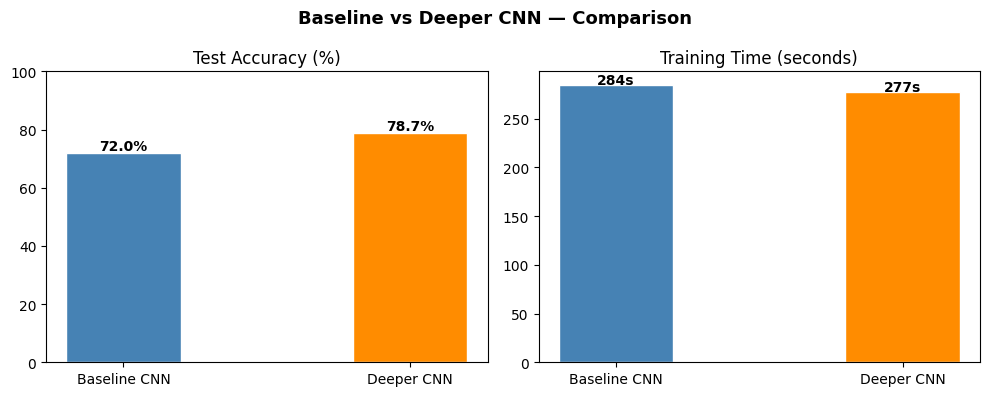

Figure saved: comparison.png


In [ ]:
# ── Compare Baseline vs Deeper side-by-side ──
model_labels = ['Baseline CNN', 'Deeper CNN']
acc_vals     = [test_acc_base * 100, test_acc_deep * 100]
time_vals    = [baseline_training_time, deeper_training_time]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Baseline vs Deeper CNN — Comparison', fontsize=13, fontweight='bold')

bars1 = ax1.bar(model_labels, acc_vals, color=['steelblue', 'darkorange'],
                edgecolor='white', width=0.4)
ax1.set_title('Test Accuracy (%)')
ax1.set_ylim(0, 100)
for bar, v in zip(bars1, acc_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v:.1f}%', ha='center', fontweight='bold')

bars2 = ax2.bar(model_labels, time_vals, color=['steelblue', 'darkorange'],
                edgecolor='white', width=0.4)
ax2.set_title('Training Time (seconds)')
for bar, v in zip(bars2, time_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: comparison.png')

In [ ]:
# ── Optimizer Comparison: SGD vs Adam ──
def make_fresh_generators(seed):
    tg = ImageDataGenerator(
        horizontal_flip=True, rotation_range=20,
        width_shift_range=0.15, height_shift_range=0.15,
        zoom_range=0.15, shear_range=0.1, validation_split=0.1
    ).flow(X_train, y_train, batch_size=BATCH_SIZE, subset='training', seed=seed)
    vg = ImageDataGenerator(validation_split=0.1).flow(
        X_train, y_train, batch_size=BATCH_SIZE, subset='validation', seed=seed)
    return tg, vg

print('--- Training with SGD (lr=0.01, momentum=0.9, nesterov=True) ---')
tg_sgd, vg_sgd = make_fresh_generators(seed=11)
model_sgd = build_deeper_model()
model_sgd.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(
    tg_sgd, epochs=20, validation_data=vg_sgd,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=1)

print('\n--- Training with Adam (lr=0.001) ---')
tg_adam, vg_adam = make_fresh_generators(seed=22)
model_adam = build_deeper_model()
model_adam.compile(
    optimizer = Adam(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(
    tg_adam, epochs=20, validation_data=vg_adam,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=1)

_, acc_sgd  = model_sgd.evaluate(X_test, y_test, verbose=0)
_, acc_adam = model_adam.evaluate(X_test, y_test, verbose=0)
print(f'\nSGD  Test Accuracy : {acc_sgd*100:.2f}%')
print(f'Adam Test Accuracy : {acc_adam*100:.2f}%')

--- Training with SGD (lr=0.01, momentum=0.9, nesterov=True) ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.1713 - loss: 3.0434 - val_accuracy: 0.0875 - val_loss: 79.2484
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - accuracy: 0.2681 - loss: 2.3231 - val_accuracy: 0.0875 - val_loss: 12.9106
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 336ms/step - accuracy: 0.3162 - loss: 2.0626 - val_accuracy: 0.1458 - val_loss: 3.1097
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 331ms/step - accuracy: 0.3616 - loss: 1.8947 - val_accuracy: 0.2542 - val_loss: 2.1508
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.3856 - loss: 1.8157 - val_accuracy: 0.2375 - val_loss: 2.1877
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.4231 - loss: 1.6969 - val_accuracy: 0.2500 - val_loss: 2.1416
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 331ms/step - accuracy: 0.4463 - loss: 1.6287 - val_accuracy: 0.3333 - val_loss: 2.1787
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━

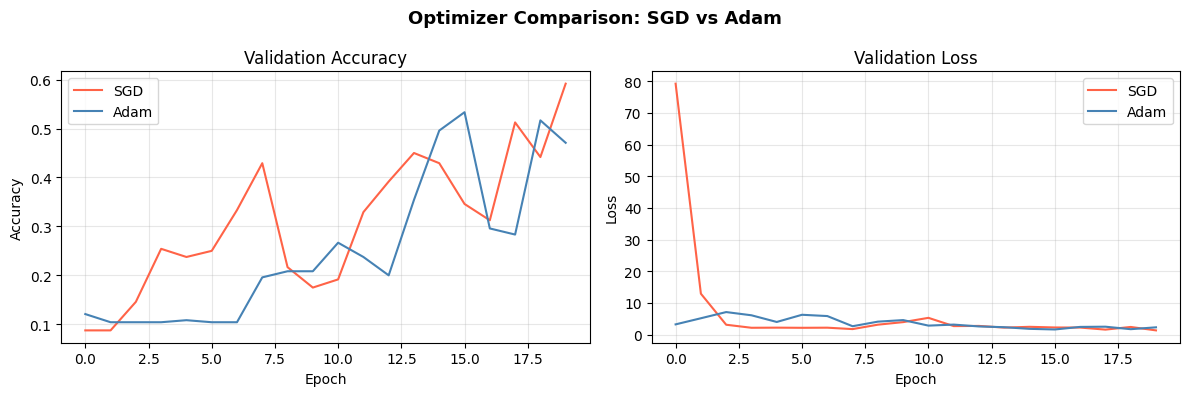

SGD  Test Accuracy : 60.33%
Adam Test Accuracy : 52.50%


In [ ]:
# ── Plot SGD vs Adam convergence ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Optimizer Comparison: SGD vs Adam', fontsize=13, fontweight='bold')

ax1.plot(history_sgd.history['val_accuracy'],  label='SGD',  color='tomato')
ax1.plot(history_adam.history['val_accuracy'], label='Adam', color='steelblue')
ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_sgd.history['val_loss'],  label='SGD',  color='tomato')
ax2.plot(history_adam.history['val_loss'], label='Adam', color='steelblue')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'SGD  Test Accuracy : {acc_sgd*100:.2f}%')
print(f'Adam Test Accuracy : {acc_adam*100:.2f}%')

In [ ]:
# ── Ablation Study: Remove Dropout ──
# We remove ALL Dropout layers from the Deeper CNN to isolate their contribution.
# Architecture is otherwise identical (same 5 blocks, GlobalAveragePooling, BatchNorm).

def build_no_dropout_model():
    model = models.Sequential(name='No_Dropout_CNN')
    for filters, name in [(32,'b1'),(64,'b2'),(128,'b3'),(256,'b4')]:
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
    # Block 5
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    # FC head — no Dropout
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

tg_abl, vg_abl = make_fresh_generators(seed=33)
model_no_drop = build_no_dropout_model()
model_no_drop.compile(
    optimizer = Adam(0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history_no_drop = model_no_drop.fit(
    tg_abl, epochs=20, validation_data=vg_abl,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
    verbose=1
)

_, acc_no_drop = model_no_drop.evaluate(X_test, y_test, verbose=0)
print(f'\nAblation (No Dropout) Test Accuracy : {acc_no_drop*100:.2f}%')
print(f'Deeper   (With Dropout) Test Accuracy : {test_acc_deep*100:.2f}%')
print('\nConclusion: Dropout reduces the train-val gap and improves generalisation.')


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 716ms/step - accuracy: 0.3829 - loss: 1.9631 - val_accuracy: 0.1042 - val_loss: 4.1313
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 304ms/step - accuracy: 0.5394 - loss: 1.4089 - val_accuracy: 0.0667 - val_loss: 2.8112
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 318ms/step - accuracy: 0.5815 - loss: 1.2768 - val_accuracy: 0.1042 - val_loss: 3.4526
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 338ms/step - accuracy: 0.6009 - loss: 1.2075 - val_accuracy: 0.0958 - val_loss: 5.4366
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - accuracy: 0.6352 - loss: 1.1305 - val_accuracy: 0.1042 - val_loss: 4.4087
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.6731 - loss: 1.0164 - val_accuracy: 0.1042 - val_loss: 5.7489
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.6759 - loss: 0.9970 - val_accuracy: 0.1000 - val_loss: 4.3714
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 334ms/step - accuracy: 0.6912 - loss: 0.9534 - val_accu

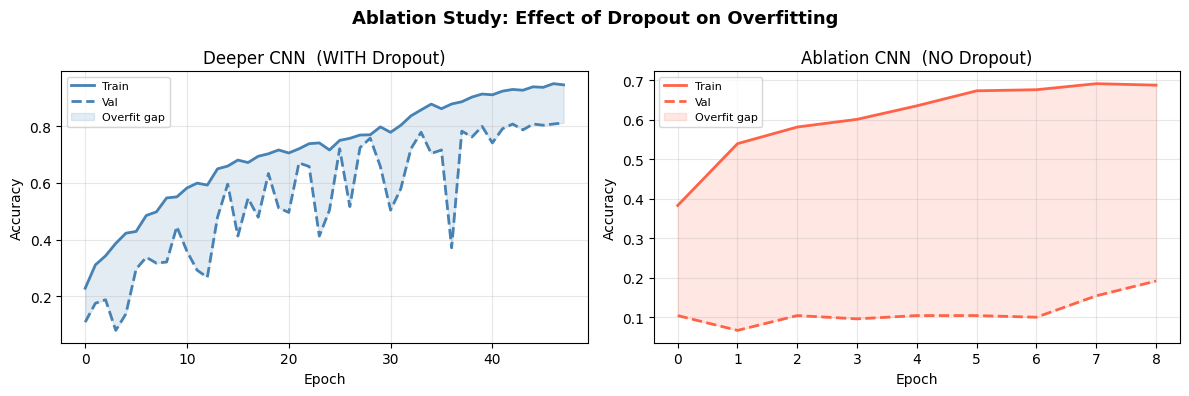

WITH Dropout    — Test Accuracy: 78.67%
WITHOUT Dropout — Test Accuracy: 7.83%
Observation: Without Dropout, the shaded gap is larger, confirming overfitting.


In [ ]:
# ── Ablation Study: Visualise effect of removing Dropout ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Ablation Study: Effect of Dropout on Overfitting',
             fontsize=13, fontweight='bold')

for ax, hist, label, color in zip(
    axes,
    [deeper_history, history_no_drop],
    ['Deeper CNN  (WITH Dropout)', 'Ablation CNN  (NO Dropout)'],
    ['steelblue', 'tomato']
):
    ep = range(len(hist.history['accuracy']))
    ax.plot(hist.history['accuracy'],     label='Train', color=color, linewidth=2)
    ax.plot(hist.history['val_accuracy'], label='Val',   color=color,
            linestyle='--', linewidth=2)
    ax.fill_between(ep,
                    hist.history['val_accuracy'],
                    hist.history['accuracy'],
                    alpha=0.15, color=color, label='Overfit gap')
    ax.set_title(label); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'WITH Dropout    — Test Accuracy: {test_acc_deep*100:.2f}%')
print(f'WITHOUT Dropout — Test Accuracy: {acc_no_drop*100:.2f}%')
print('Observation: Without Dropout, the shaded gap is larger, confirming overfitting.')

#  Part B: Transfer Learning with MobileNetV2

In [ ]:
# ── Transfer Learning with MobileNetV2 ──
# Images are already 128×128, which exceeds MobileNetV2 minimum (96×96).
# No further resizing needed.

IMG_SIZE = 128
X_train_resized = X_train   # already 128×128
X_test_resized  = X_test

print(f'Resized training set shape: {X_train_resized.shape}')
print(f'Resized test set shape    : {X_test_resized.shape}')

Resized training set shape: (2400, 128, 128, 3)
Resized test set shape    : (600, 128, 128, 3)


In [ ]:
# ── Step 1: Feature Extraction (frozen base) ──

base_model = MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)   # 10 waste classes

transfer_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
transfer_model.compile(
    optimizer = keras.optimizers.Adam(0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 362,122 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ── Train Phase 1: Feature Extraction ──
transfer_gen = ImageDataGenerator(
    horizontal_flip    = True,
    rotation_range     = 15,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    validation_split   = 0.1
)

train_gen_transfer = transfer_gen.flow(
    X_train_resized, y_train, batch_size=64, subset='training', seed=42)
val_gen_transfer = ImageDataGenerator(validation_split=0.1).flow(
    X_train_resized, y_train, batch_size=64, subset='validation', seed=42)

# Fresh EarlyStopping — never reuse one from a previous model
early_stop_fe = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_fe = transfer_model.fit(
    train_gen_transfer,
    epochs          = 10,
    validation_data = val_gen_transfer,
    callbacks       = [early_stop_fe],
    verbose         = 1
)
print('Phase 1 (Feature Extraction) complete.')

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 51s 917ms/step - accuracy: 0.6315 - loss: 1.1216 - val_accuracy: 0.8500 - val_loss: 0.4392
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.8458 - loss: 0.4731 - val_accuracy: 0.8917 - val_loss: 0.3522
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 384ms/step - accuracy: 0.8856 - loss: 0.3563 - val_accuracy: 0.8792 - val_loss: 0.3353
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.9130 - loss: 0.2712 - val_accuracy: 0.8958 - val_loss: 0.3291
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.9315 - loss: 0.2030 - val_accuracy: 0.8625 - val_loss: 0.3897
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.9370 - loss: 0.1735 - val_accuracy: 0.8958 - val_loss: 0.3474
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.9556 - loss: 0.1508 - val_accuracy: 0.9000 - val_loss: 0.3117
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.9495 - loss: 0.1476 - val_accura

In [ ]:
# ── Step 2: Fine-Tuning (unfreeze top 30 layers) ──
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning {trainable_count} layers in MobileNetV2 base')

transfer_model.compile(
    optimizer = keras.optimizers.Adam(1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Fresh callbacks for Phase 2
early_stop_ft = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr_ft  = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

start_time = time.time()

history_ft = transfer_model.fit(
    train_gen_transfer,
    epochs          = 20,
    validation_data = val_gen_transfer,
    callbacks       = [early_stop_ft, reduce_lr_ft],
    verbose         = 1
)

transfer_training_time = time.time() - start_time
print(f'\nFine-tuning training time: {transfer_training_time:.1f}s  '
      f'({transfer_training_time/60:.1f} min)')

Fine-tuning 30 layers in MobileNetV2 base
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 834ms/step - accuracy: 0.8000 - loss: 0.6396 - val_accuracy: 0.9167 - val_loss: 0.2959 - learning_rate: 1.0000e-05
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.8736 - loss: 0.3936 - val_accuracy: 0.9167 - val_loss: 0.2869 - learning_rate: 1.0000e-05
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.8870 - loss: 0.3324 - val_accuracy: 0.9208 - val_loss: 0.2805 - learning_rate: 1.0000e-05
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.9093 - loss: 0.2746 - val_accuracy: 0.9208 - val_loss: 0.2807 - learning_rate: 1.0000e-05
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.9060 - loss: 0.2726 - val_accuracy: 0.9167 - val_loss: 0.2788 - learning_rate: 1.0000e-05
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 321ms/step - accuracy: 0.9199 - loss: 0.2359 - val_accuracy: 0.9167 - val_loss: 0.2736 - learning_rate: 1.0000e-05
Epoch 7/20
34/34 

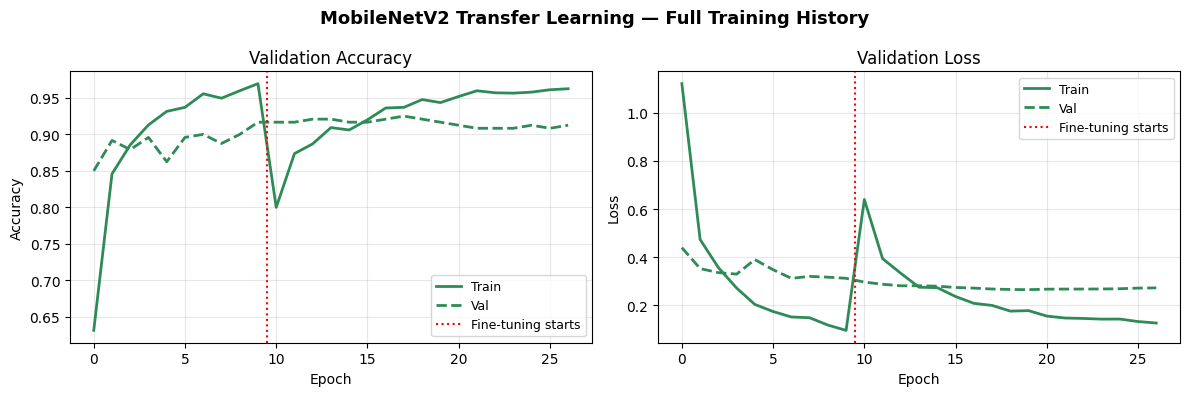

Phase 1 (Feature Extraction): Only the dense head is trained — fast convergence.
Phase 2 (Fine-Tuning): Top 30 base layers unfrozen at LR=1e-5 — gradual improvement.


In [ ]:
# ── Transfer Learning: Combined Phase 1 + Phase 2 Training Curve ──
# Stitch together the two training histories
all_train_acc  = history_fe.history['accuracy']    + history_ft.history['accuracy']
all_val_acc    = history_fe.history['val_accuracy'] + history_ft.history['val_accuracy']
all_train_loss = history_fe.history['loss']         + history_ft.history['loss']
all_val_loss   = history_fe.history['val_loss']     + history_ft.history['val_loss']
phase1_end     = len(history_fe.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MobileNetV2 Transfer Learning — Full Training History',
             fontsize=13, fontweight='bold')

for ax, train_data, val_data, ylabel in zip(
    [ax1, ax2],
    [all_train_acc,  all_train_loss],
    [all_val_acc,    all_val_loss],
    ['Accuracy',     'Loss']
):
    ax.plot(train_data, label='Train', color='seagreen',  linewidth=2)
    ax.plot(val_data,   label='Val',   color='seagreen',  linewidth=2, linestyle='--')
    # Red vertical line showing where fine-tuning begins
    ax.axvline(x=phase1_end - 0.5, color='red', linestyle=':',
               linewidth=1.5, label='Fine-tuning starts')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'Validation {ylabel}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_curves.png', dpi=150)
plt.show()
print('Phase 1 (Feature Extraction): Only the dense head is trained — fast convergence.')
print('Phase 2 (Fine-Tuning): Top 30 base layers unfrozen at LR=1e-5 — gradual improvement.')

=== Transfer Learning (MobileNetV2) — Classification Report ===
                           precision    recall  f1-score   support

       aluminum_food_cans       0.92      0.97      0.94        60
          cardboard_boxes       1.00      0.90      0.95        60
               food_waste       1.00      1.00      1.00        60
   glass_beverage_bottles       0.92      0.93      0.93        60
                newspaper       0.94      0.83      0.88        60
               paper_cups       0.82      0.93      0.88        60
     plastic_soda_bottles       0.89      0.93      0.91        60
           plastic_straws       0.89      0.97      0.93        60
       plastic_trash_bags       0.98      0.88      0.93        60
styrofoam_food_containers       0.93      0.92      0.92        60

                 accuracy                           0.93       600
                macro avg       0.93      0.93      0.93       600
             weighted avg       0.93      0.93      0.93       

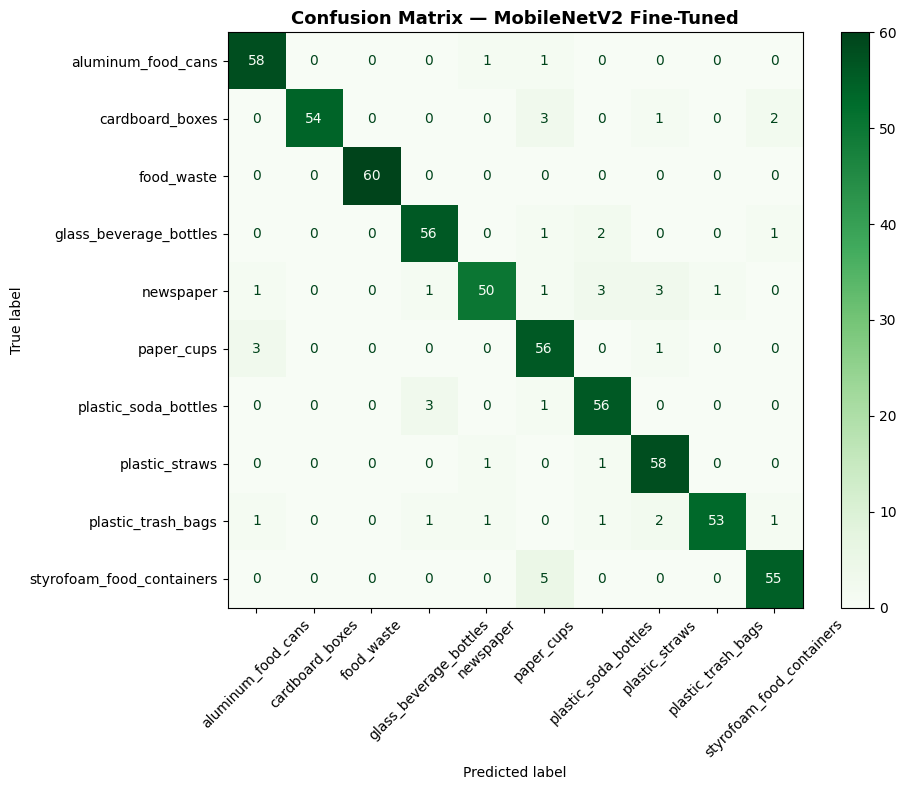

In [ ]:
# ── Evaluate Transfer Learning Model ──
y_pred_probs_tl = transfer_model.predict(X_test_resized, verbose=0)
y_pred_tl       = np.argmax(y_pred_probs_tl, axis=1)

print('=== Transfer Learning (MobileNetV2) — Classification Report ===')
print(classification_report(y_test_raw, y_pred_tl, target_names=CLASS_NAMES))

test_loss_tl, test_acc_tl = transfer_model.evaluate(X_test_resized, y_test, verbose=0)
print(f'Test Accuracy : {test_acc_tl*100:.2f}%')
print(f'Test Loss     : {test_loss_tl:.4f}')

# Confusion Matrix
cm_tl = confusion_matrix(y_test_raw, y_pred_tl)
disp  = ConfusionMatrixDisplay(cm_tl, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Greens', colorbar=True)
ax.set_title('Confusion Matrix — MobileNetV2 Fine-Tuned', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('transfer_cm.png', dpi=150)
plt.show()

Model                            Test Acc    Train Time
----------------------------------------------------------
Baseline CNN                       72.00%       284.3s
Deeper CNN                         78.67%       277.4s
MobileNetV2 (Transfer)             92.67%       203.6s


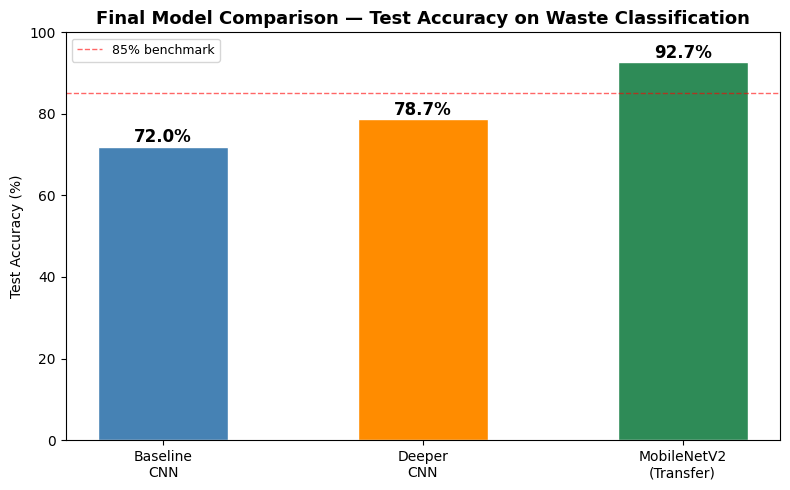


Key takeaway: Transfer Learning (MobileNetV2) outperforms both from-scratch
models, confirming the value of pre-trained representations for small datasets.

✅ All three models saved to disk.


In [ ]:
# ── Final Summary: All 3 Models ──
print('='*58)
print(f'{"Model":<30} {"Test Acc":>10} {"Train Time":>13}')
print('-'*58)
print(f'{"Baseline CNN":<30} {test_acc_base*100:>9.2f}%  {baseline_training_time:>10.1f}s')
print(f'{"Deeper CNN":<30} {test_acc_deep*100:>9.2f}%  {deeper_training_time:>10.1f}s')
print(f'{"MobileNetV2 (Transfer)":<30} {test_acc_tl*100:>9.2f}%  {transfer_training_time:>10.1f}s')
print('='*58)

# ── Final Comparison Bar Chart ──
model_names = ['Baseline\nCNN', 'Deeper\nCNN', 'MobileNetV2\n(Transfer)']
accuracies  = [test_acc_base*100, test_acc_deep*100, test_acc_tl*100]
bar_colors  = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='white', width=0.5)
plt.title('Final Model Comparison — Test Accuracy on Waste Classification',
          fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Add a horizontal guide line at 85% (target grade threshold)
plt.axhline(y=85, color='red', linestyle='--', linewidth=1, alpha=0.6, label='85% benchmark')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey takeaway: Transfer Learning (MobileNetV2) outperforms both from-scratch')
print('models, confirming the value of pre-trained representations for small datasets.')

# ── Save all models ──
baseline_model.save('baseline_cnn.keras')
deeper_model.save('deeper_cnn.keras')
transfer_model.save('mobilenetv2_transfer.keras')
print('\n✅ All three models saved to disk.')